# Практическая работа 3: "Предобработка изображений с использованием библиотеки OpenCV"

**Задание 1**. Подключение библиотеки OpenCV

Если есть в этом необходимость, то установите библиотеку `!pip install opencv-python`.  

In [ ]:
import cv2
print(cv2.__version__)

4.13.0


**Задание 2**. Начало работы с OpenCV

2.1.   Перед началом работы нужно загрузить на Google Диск все необходимые для работы изображения.

2.2.   Затем подключить Google Диск к данному Notebook  либо через меню «Файлы» (значок папки) -> «Подключить диск», либо прописав приведенный код самостоятельно:
```
from google.colab import drive
drive.mount('/content/drive')
```
Это позволяет читать и сохранять данные напрямую, используя путь к файлам, который будет начинаться с `/content/drive/MyDrive/`

In [ ]:
#ВАШ КОД

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!apt-get install unrar

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 7 not upgraded.


In [ ]:
!unrar x "/content/drive/MyDrive/Colab Notebooks/Машинное обучение 3-2/lab3/images.rar" "/content/images/"


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from /content/drive/MyDrive/Colab Notebooks/Машинное обучение 3-2/lab3/images.rar

Creating    /content/images                                           OK
Creating    /content/images/images                                    OK
Creating    /content/images/images/data                               OK
Creating    /content/images/images/data/black                         OK
Extracting  /content/images/images/data/black/black1.jpg                   0%  OK 
Extracting  /content/images/images/data/black/black10.jpg                  0%  OK 
Extracting  /content/images/images/data/black/black11.jpg                  0%  OK 
Extracting  /content/images/images/data/black/black12.jpg                  0%  OK 
Extracting  /content/images/images/data/black/black13.jpg                  1%  OK 
Extracting  /content/images/images/data/black/black14.jpg                 

In [ ]:
import os
os.listdir('/content/images/images')
#os.listdir('/content/images/images/data')
#os.listdir('/content/images/images/data/polar')

['data', 'example.jpg']

2.3.   Далее выберите любое понравившееся Вам изображение и загрузите его для работы.

In [ ]:
import numpy as np
from pathlib import Path

path = Path(r"/content/images/images/data/polar/polar_bear1.jpg") #вставьте путь к файлу

img = cv2.imdecode(np.fromfile(path, dtype=np.uint8), cv2.IMREAD_COLOR) #в случае наличия в пути кириллицы

print(img.shape)

(183, 275, 3)


Размера изображения - (1080, 1920, 3) это Full HD фото, где 3 означает цвета (Red, Green, Blue).

2.4. Выведем изображение на экран, используя библиотеку Matplotlib.

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

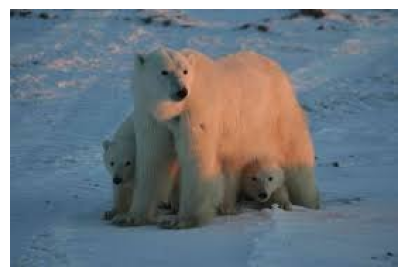

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
#plt.imshow(img)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Конвертация BGR в RGB
plt.axis('off') # Отключение осей координат

**Задание 3**. Поработаем с цветом

3.1. Представьте изображение в исходной цветовой палитре.

3.2. Представьте изображение в градации серого.

3.3. Представьте изображение в черно-белом формате.

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

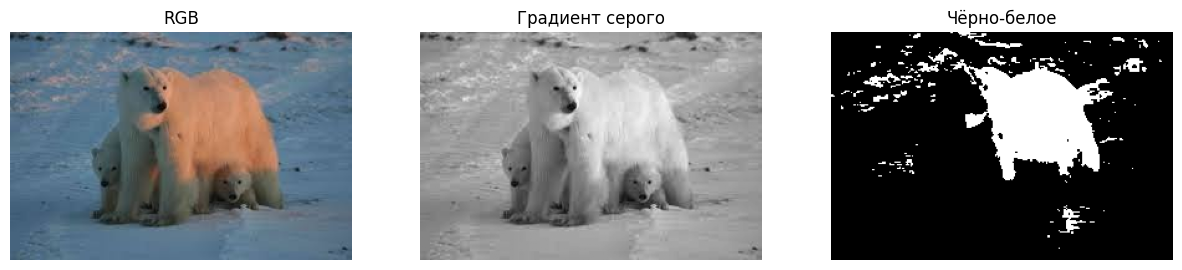

In [ ]:
#ВАШ КОД, пример вывода смотри ниже

import cv2

plt.figure(figsize=(15, 5))

# RGB - 3.1
plt.subplot(1, 3, 1)
plt.title("RGB")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

# Grayscale - 3.2
plt.subplot(1, 3, 2)
plt.title("Градиент серого")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.axis('off')

# Black & White - 3.3
plt.subplot(1, 3, 3)
plt.title("Чёрно-белое")
plt.imshow(cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)[1], cmap='gray')
plt.axis('off')

Ответьте на следующие вопросы:

1.   Какой формат цвета использует OpenCV? Какие особенности работы в этим форматом нужно учитывать?
2.   Для чего может понадобиться преобразование цвета?

Ответы на вопросы:

1. OpenCV использует формат BGR (Blue, Green, Red), а не RGB. При отображении через matplotlib нужно делать преобразование из BGR в RGB, иначе цвета будут искажены.

2. Корректность отображения изображений, упрощение обработки (например, перевод в grayscale) и выделения объектов (бинаризация, фильтрация)

**Задание 4**. Операции с изображением

4.1. Необходимо уменьшить изображение в три раза, используя, например команду `resize()`.

4.2. Необходимо уменьшить изображение, задав итоговый размер.

4.3. Обрежьте изображение так, чтобы остался только ваш объект.

4.4. Поверните изображение от 30 до 180 градусов с шагом 30 градусов.

4.5. Используйте размытие изображения для удаления шумов.

(np.float64(-0.5), np.float64(274.5), np.float64(182.5), np.float64(-0.5))

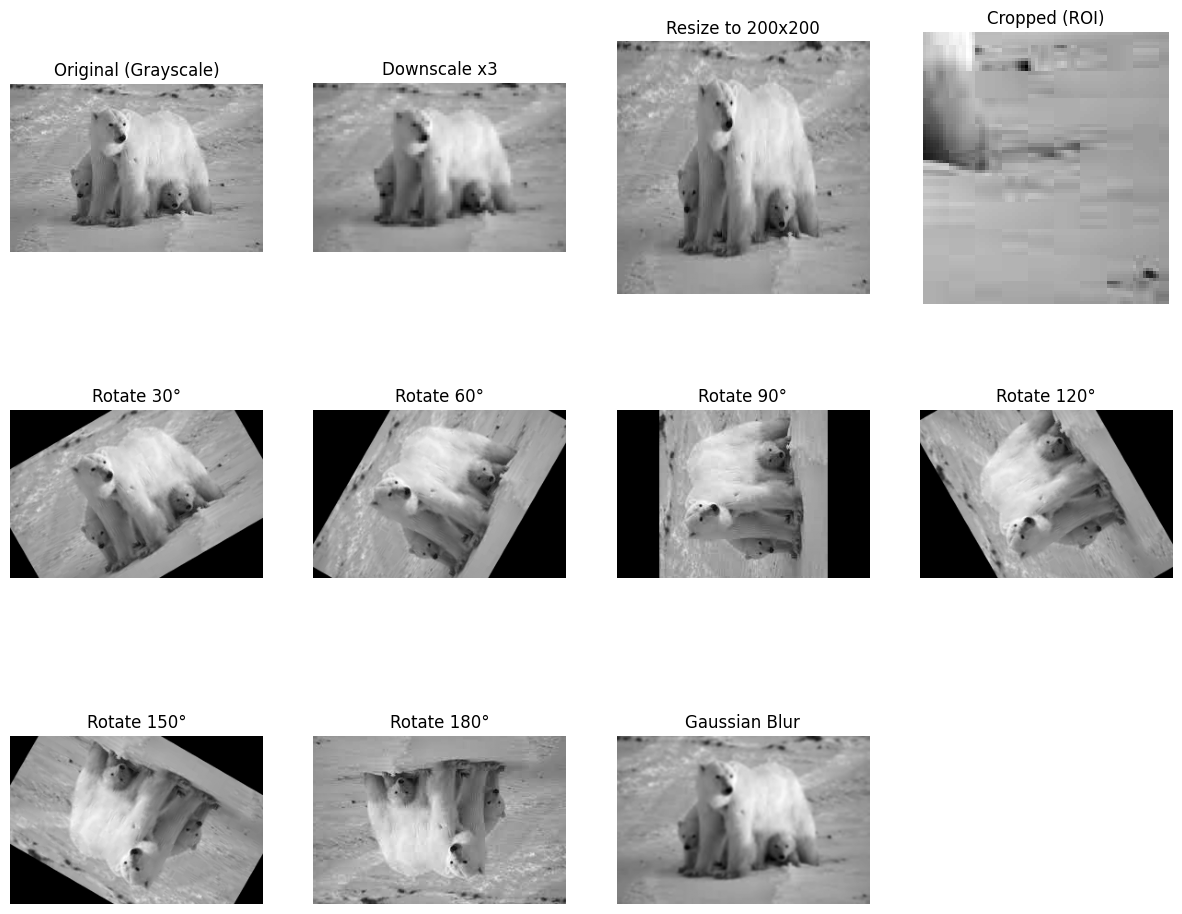

In [ ]:
#ВАШ КОД, пример вывода смотри ниже

# размеры
h, w = gray.shape

# 4.1 уменьшение в 3 раза (с интерполяцией)
downscaled = cv2.resize(gray, (w//3, h//3), interpolation=cv2.INTER_AREA)

# 4.2 изменение размера
resized = cv2.resize(gray, (200, 200))

# 4.3 обрезка
cropped = gray[100:400, 200:500]

# 4.4 повороты
center = (w // 2, h // 2)

rotated_30 = cv2.warpAffine(gray, cv2.getRotationMatrix2D(center, 30, 1.0), (w, h))
rotated_60 = cv2.warpAffine(gray, cv2.getRotationMatrix2D(center, 60, 1.0), (w, h))
rotated_90 = cv2.warpAffine(gray, cv2.getRotationMatrix2D(center, 90, 1.0), (w, h))
rotated_120 = cv2.warpAffine(gray, cv2.getRotationMatrix2D(center, 120, 1.0), (w, h))
rotated_150 = cv2.warpAffine(gray, cv2.getRotationMatrix2D(center, 150, 1.0), (w, h))
rotated_180 = cv2.warpAffine(gray, cv2.getRotationMatrix2D(center, 180, 1.0), (w, h))

# 4.5 размытие
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# вывод
plt.figure(figsize=(15, 12))

# 1 ряд
plt.subplot(3, 4, 1)
plt.title("Original (Grayscale)")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(3, 4, 2)
plt.title("Downscale x3")
plt.imshow(downscaled, cmap='gray')
plt.axis('off')

plt.subplot(3, 4, 3)
plt.title("Resize to 200x200")
plt.imshow(resized, cmap='gray')
plt.axis('off')

plt.subplot(3, 4, 4)
plt.title("Cropped (ROI)")
plt.imshow(cropped, cmap='gray')
plt.axis('off')

# 2 ряд
plt.subplot(3, 4, 5)
plt.title("Rotate 30°")
plt.imshow(rotated_30, cmap='gray')
plt.axis('off')

plt.subplot(3, 4, 6)
plt.title("Rotate 60°")
plt.imshow(rotated_60, cmap='gray')
plt.axis('off')

plt.subplot(3, 4, 7)
plt.title("Rotate 90°")
plt.imshow(rotated_90, cmap='gray')
plt.axis('off')

plt.subplot(3, 4, 8)
plt.title("Rotate 120°")
plt.imshow(rotated_120, cmap='gray')
plt.axis('off')

# 3 ряд
plt.subplot(3, 4, 9)
plt.title("Rotate 150°")
plt.imshow(rotated_150, cmap='gray')
plt.axis('off')

plt.subplot(3, 4, 10)
plt.title("Rotate 180°")
plt.imshow(rotated_180, cmap='gray')
plt.axis('off')

plt.subplot(3, 4, 11)
plt.title("Gaussian Blur")
plt.imshow(blurred, cmap='gray')
plt.axis('off')

**Задание 5**. Детекция объектов

**Детекция объектов** (*Object Detection*) — это задача компьютерного зрения, объединяющая классификацию (что изображено) и локализацию (где находится) объектов на изображении или видео. Она находит объекты, рисуя вокруг них ограничивающие рамки (bounding boxes) с метками классов и оценкой достоверности.

Выделить контуры вашего объекта, используйте ***drawContours()***.

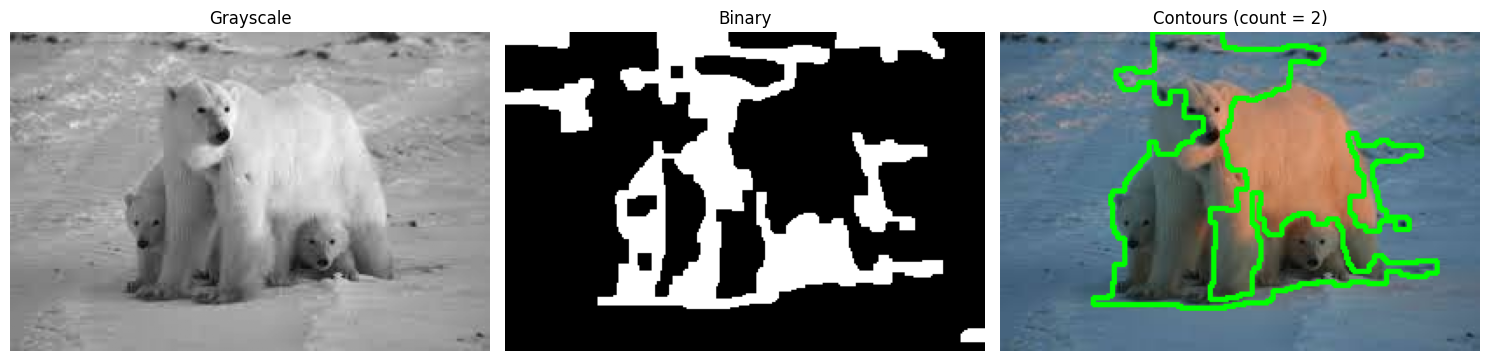

In [ ]:
#ВАШ КОД, пример вывода смотри ниже

# 0. перевод в серый
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. размытие для уменьшения шума
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 2. бинаризация через детектор рёбер Canny
binary = cv2.Canny(blurred, threshold1=30, threshold2=100)

# 3. морфология - соединяем разрывы в контурах
kernel = np.ones((3, 3), np.uint8)
binary = cv2.dilate(binary, kernel, iterations=2)
binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel, iterations=3)

# 4. поиск контуров
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 5. рисуем только крупные контуры (фильтруем мелкий шум)
contour_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).copy()
big_contours = [c for c in contours if cv2.contourArea(c) > 750]
cv2.drawContours(contour_img, big_contours, -1, (0, 255, 0), 2)

# 6. вывод
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.title("Grayscale"); plt.imshow(gray, cmap='gray'); plt.axis('off')
plt.subplot(1, 3, 2); plt.title("Binary"); plt.imshow(binary, cmap='gray'); plt.axis('off')
plt.subplot(1, 3, 3); plt.title(f"Contours (count = {len(big_contours)})"); plt.imshow(contour_img); plt.axis('off')
plt.tight_layout(); plt.show()

**Задание 6**. Применение набора данных для решение задачи классификации

Попробуем выполнить классификацию изображений по 5 классам медведей. И проверим качество работы модели на конкретном примере `eхample.jpg`.

In [ ]:
import os

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
DATASET_PATH = "/content/images/images/data"       #вставьте путь к файлу
CLASSES = ["black", "grizzly", "panda", "polar", "teddy"]

images = []
labels = []

for label, cls in enumerate(CLASSES):
    class_path = os.path.join(DATASET_PATH, cls)

    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)

        img = cv2.imread(img_path)
        if img is None:
            continue

        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_gray = cv2.resize(img_gray, (128, 128))

        images.append(img_gray)
        labels.append(label)

X = np.array(images)
y = np.array(labels)

print(X.shape, y.shape)

(309, 128, 128) (309,)


In [ ]:
from skimage.feature import hog

In [ ]:
def extract_hog_features(images):
    features = []

    for img in images:
        hog_feat = hog(
            img,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm='L2-Hys'
        )
        features.append(hog_feat)

    return np.array(features)

In [ ]:
X_features = extract_hog_features(X)

print(X_features.shape)

(309, 8100)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
model = SVC(kernel='linear', probability=True)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))  # Для чего делать на обучающую и тестовые выборки
print(classification_report(y_test, y_pred, target_names=CLASSES))  # Вывод проверить
# Точность | Полнота(сколько нашла реальных панд) | СР precision&recall | Кол-во объектов этого класса


Accuracy: 0.5512820512820513
              precision    recall  f1-score   support

       black       0.50      0.59      0.54        17
     grizzly       0.36      0.33      0.35        12
       panda       0.00      0.00      0.00        11
       polar       0.64      0.84      0.72        25
       teddy       0.62      0.62      0.62        13

    accuracy                           0.55        78
   macro avg       0.42      0.48      0.45        78
weighted avg       0.47      0.55      0.51        78



polar


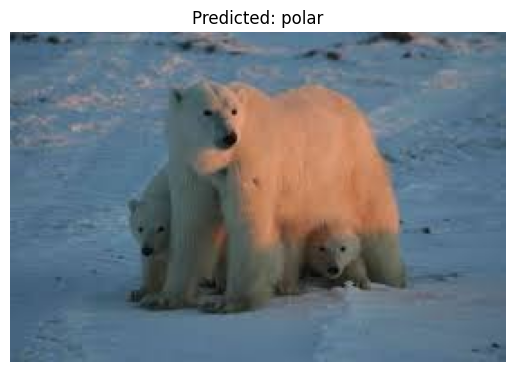

In [ ]:
def predict_image(img_path):
    img = cv2.imread(img_path)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.resize(img_gray, (128, 128))

    feat = extract_hog_features([img_gray])
    pred = model.predict(feat)[0]

    return CLASSES[pred]

print(predict_image("/content/images/images/data/polar/polar_bear1.jpg"))         #вставьте путь к файлу

img = cv2.imread("/content/images/images/data/polar/polar_bear1.jpg")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Predicted: {predict_image('/content/images/images/data/polar/polar_bear1.jpg')}")
plt.axis('off')
plt.show()

Вопрос:

1.   Почему получен такой результат?
2.   Как можно повысить качество модели?


Ваши ответы:

1.   Результат:
  
Маленький датасет: всего 309 изображений на 5 классов, в среднем по 60 на класс. SVM плохо обобщает на таком объёме

HOG: не лучший дескриптор для медведей - он хорошо работает для объектов с чёткой формой (люди, машины), но медведи разных видов похожи по силуэту

Серый цвет: потеря цветовой информации, а цвет (белый/чёрный/бурый) — один из главных признаков различия видов

Классы похожи визуально: grizzly и black bear очень похожи по форме, отсюда низкие 0.29–0.45 precision у них

2.   Повышение качества модели:

Добавить цвет: извлекать HOG из трёх каналов (BGR/HSV) вместо grayscale

Больше данных: аугментация (повороты, отражения, яркость) или дополнительные изображения

Другие признаки: LBP (текстура шерсти) в дополнение к HOG

Другая модель: SVM с kernel='rbf' вместо linear, или перейти на CNN (ResNet, EfficientNet) - даст 90%+

Нормализация признаков - StandardScaler перед подачей в SVM






**Задание 7**. **NoCode** платформы для работы с данными.


 7.1. Перейти по ссылке https://app.roboflow.com/login.

 7.2. Пройдите процедуру регистрации.

 7.3. Создайте свой собственный проект.

 7.4. Выберите загрузку собственных данных.

 7.5. Заполните название проекта, выберите тип лицензии, тип вашего проекта и кратко укажите что будет вашей целью.

 7.6. Загрузите ваши изображения (не менее 30) в проект.

 7.7. Выполните ручную разметку данных.

 7.8. После того как все изображения размечены, добавьте эту разметку к вашему набору данных.

7.9. Разделите данные на обучающую, тестовую и валидационную выборки.

7.10. После этого можно сгенерировать новую версию датасета, уже готового к обучению.

7.11. Внимательно изучаем доступные параметры и выбираем то, что позволит сделать ваш набор данных лучше для обучения. Например, выбираем параметры предобработки и аументации.

7.12. В качестве ***ответа на задание*** необходимо вставить ***скриншот проекта*** из браузера с разметкой.

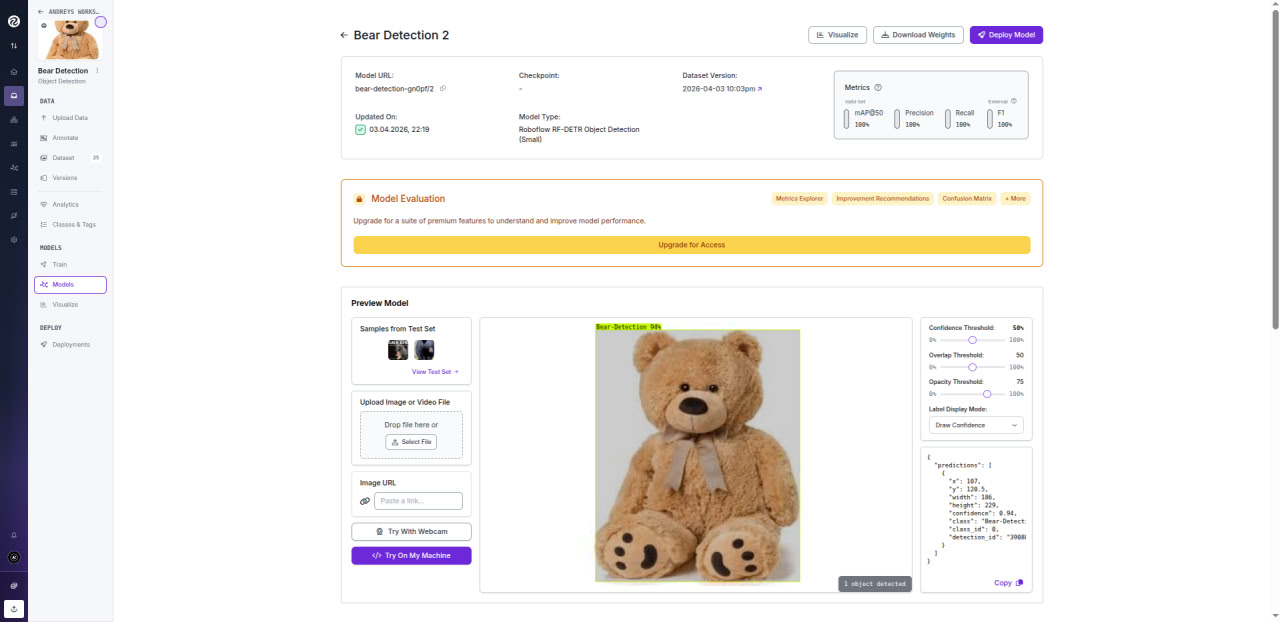

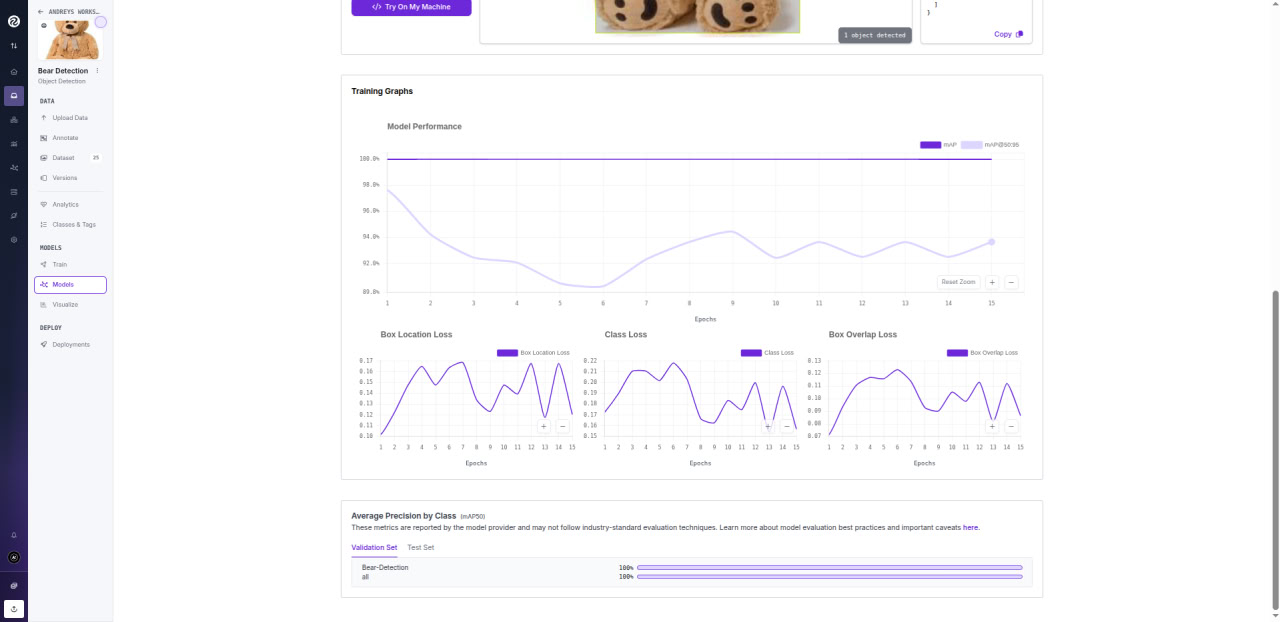